# MCDI504 - Machine Learning I
## Evaluación Sumativa 2 - Informe Final de Proyecto: Fases 2 y 3
### Regresión supervisada y redes neuronales para clasificación

**Integrantes:** Enzo Pinilla, Claudio Alarcón y Luis Rodrigo Espinoza  
**Docente:** David Ruete Zúñiga  
**Grupo:** 2  
**Fecha:** 23-08-2026  
**Repositorio:** https://github.com/sauriomac/MCDI504_MACHINE_LEARNING_1_GRUPO_2

Este notebook integra las evidencias técnicas exigidas para **RA2 (regresión supervisada)** y **RA3 (clasificación supervisada mediante redes neuronales)**. La Fase 2 utiliza una variable objetivo continua (`fare`) y la Fase 3 utiliza la variable objetivo binaria `survived`. El flujo se mantiene reproducible, con particiones entrenamiento/prueba, métricas tabuladas, ajuste de hiperparámetros y conclusiones basadas en resultados.

## 0. Reproducibilidad del entorno

El notebook está preparado para ejecutarse en orden mediante **Restart Kernel → Run All**. Se requiere Python 3 y las librerías `pandas`, `numpy`, `matplotlib`, `seaborn` y `scikit-learn`, incluidas en `requirements.txt`.

La estructura relevante para esta entrega es:

```text
MCDI504_MACHINE_LEARNING_1_GRUPO_2/
├── docs/
│   └── MCDI504_F3_S03_grupo2.pdf
├── figures/
│   └── fase3_redes_neuronales/
├── notebooks/
│   └── F3_RedesNeuronales.ipynb
├── .gitignore
├── README.md
└── requirements.txt
```

Los entregables de esta evaluación son el notebook ejecutable y el informe final en PDF indicado en la estructura anterior. Ambos documentan la integración de regresión supervisada y clasificación mediante redes neuronales.

**Instalación local en macOS o Linux (desde la raíz del repositorio):**

```bash
python3 -m venv .venv
source .venv/bin/activate
python -m pip install --upgrade pip
python -m pip install -r requirements.txt
python -m ipykernel install --user --name mcdi504-ml1 --display-name "Python (MCDI504 ML1)"
jupyter lab
```

**Instalación local en Windows PowerShell (desde la raíz del repositorio):**

```powershell
py -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install --upgrade pip
python -m pip install -r requirements.txt
python -m ipykernel install --user --name mcdi504-ml1 --display-name "Python (MCDI504 ML1)"
jupyter lab
```

Después de abrir Jupyter, se debe seleccionar el kernel **Python (MCDI504 ML1)** y ejecutar todas las celdas en orden.

**Google Colab:** no requiere crear `.venv`, instalar JupyterLab ni registrar un kernel local. Se debe seleccionar Python 3 y ejecutar al inicio:

```python
%pip install pandas numpy seaborn matplotlib scikit-learn
```

El dataset Titanic se intenta cargar desde `seaborn` o desde un CSV local. Si esas fuentes no están disponibles, se utiliza automáticamente una copia comprimida incluida en el notebook. Por ello, una vez instaladas las dependencias, el análisis puede ejecutarse sin conexión a Internet.

Se fija `RANDOM_STATE = 42` para reproducir las particiones y los modelos con componentes aleatorios. La separación entrenamiento/prueba es 80 % / 20 %. Los escaladores se ajustan únicamente con los datos de entrenamiento para evitar fuga de información; la búsqueda de hiperparámetros de SVR utiliza validación cruzada sobre entrenamiento.

`.venv/` y `.ipynb_checkpoints/` son elementos locales y deben permanecer excluidos mediante `.gitignore`.

Las figuras se muestran dentro del notebook y también se guardan automáticamente en `figures/fase3_redes_neuronales/`.


In [1]:
# Librerías base para entorno, datos, respaldo y visualización
from pathlib import Path
import sys, warnings, os, io, gzip, base64
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Herramientas para preparar datos y construir los modelos
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPClassifier
# Métricas para evaluar regresión y clasificación
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
from sklearn.exceptions import ConvergenceWarning
import sklearn

# Semilla común para obtener resultados reproducibles
# Carpeta portable para guardar las figuras generadas
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIG_DIR = ROOT / 'figures' / 'fase3_redes_neuronales'
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
# Versiones utilizadas en la ejecución actual
print('Python:', sys.version.split()[0])
print('pandas:', pd.__version__)
print('NumPy:', np.__version__)
print('seaborn:', sns.__version__)
print('scikit-learn:', sklearn.__version__)

Python: 3.10.4
pandas: 2.3.3
NumPy: 2.2.6
seaborn: 0.13.2
scikit-learn: 1.7.2


## 1. Carga y comprensión del dataset Titanic

El conjunto de datos contiene información demográfica, socioeconómica y de viaje de 891 pasajeros. Se utilizará el mismo dataset para dos objetivos analíticos distintos: **regresión** (predecir una magnitud continua) y **clasificación** (predecir una categoría).

In [2]:
# Copia comprimida de Titanic para ejecutar el notebook sin Internet
_TITANIC_GZ_B64 = (
    'H4sIAKpZi2oC/71d2Y7dxhF9z7dcEKxe2OSjZ6zxs6C8B7I0iYTIkqElTv4+3Hov3q6qHhsGDCMZ8pLs7lpOnTr17cfX/3z8z/P72+/vPr399u327fm/t7f/'
    'er59+/jrt99vv7/9+u7D7Z9vvz7fnn/79e3Xf69/ePzdHx++3N6+//Hp+z9+e/vp+fb++d2/zz/5x/cvf3y+vf203nX995fPz38bb/q2/5VSw3iD23hzg7K3'
    'N7e/f/j49f36f32+/f3rj+fb7c2XH98/vP3t9+9fPt8+f7k9vf307flvsF7xz+f9ej3762FQs9a3x9vTx6/fvt/++LLdZP/79X97/PD89dcvP77+6/a/52/h'
    'LtrfRU3rXcb9KZbkMdJ7ZE+y3WR7vuxJ7PkkVg+w3gJ7jPIex4OEj7HfYvtnfSnCx9ifIFx8XmjsrG+vq0tf/3h+/vxtX4d4JRxXWnP+rIVhnvb3Px4+XP7q'
    '/k9va6jXuykYRhcf/N2Hj5/eY58vWci4BG5/CHUDGECvC0laBH8b5W8D5lwFPa7PMs7bR39+9+Vz8TSN/XDcZP1nGhz6Or9cPknYD3Y+v+q6uawlbojiu44d'
    '+0Ev+0vYm15PhiOfrTF+BTDhVMzWKNK6nqcirIf1Wxq2I/bGL0b7ZGWby2ybaxlg3ZuvsYfId3fcFPFggE5/Hv8G2W/7Uw3nfoJ5v0FjT2I7+/yEan34R+z6'
    'fC+eD6AKi6Cm9vOnn/+42i/gxdv/fGXU4hZILJJaVPPrZ4bxWD5/DNZXQSzLT80VmF/AuJxeYj8LenaWY1xyA5uvY1yHuIiVeYVlfwO1ruGxDMUneKTuoNkl'
    'K5A9ObYC5XPPi53JNuR8dOMN0GqdndqtafHwyIsnNvA4OWY1gOnF6aM/tEzx+fTOct783P+Td+sw7nuPdHrGbOduLzCrAVz75f128d/ORzZWYat+vej5ZluX'
    '/N5uQ+wlyJyGP/HbW6sugxd88OrKlQEXXqDpgpPn2LfedpNlMJQDmyyAymKK7R77N2k7n8wJVmeHcugTz6f331Y3A4N1+yoKApHddvSfflE8ua/gZrRb0eTL'
    'nFn/s+pYr8k1dj4asfgjC+v3Yu2Z89fdGWyswdM0s7xNff7SR2g57GAxzeLzmTX0PA5/bTR/vtg2ceP7uyh61FWYr+nw/HCbYFhc8iDhVR6wxQh+/47Pf7wK'
    'O+LzA2q4OVHjvF5ItKFY2HoeXrXv4jfo0W2EC7C9g90MwDQsoo2kwkZivEKeGe+Hf7OkqOtNv5v3Wj6LnfVpd2nRSnhq44Mdx3zrdN/wwo1osGAzWMo0jPX1'
    'kbm/5Z4aey4Y63mALQunHv5ovg7zozgwRLlpptN9z8M0KUbW51MGJQqZ4itM2K6nee3CfGreA8TXP4LOwWw5K8mDhC0U3t5Og2nHy4jZseHMTsjHfyJAOMxI'
    'XejmQ444DutO3b7+fgA4li7Nr3yeAIoWrSFfzn/6JQk72ycnP7vLYKlLhoQrMy9gKRNc4xLcr/310zMvcXXp59e70d3DtVlmN+A4OHrDDDQPLRLuv+ColEbz'
    'YxZyqkwHUqaWnotHHCSjZtjeYK1hFjgK9IoZ/D1UWfePYOFszDCU/bOtTnht5638ut2mw05XwBAe3cQtswenetCbq60ub4bIJzYGx714IXIKrwEdnKvSlWA6'
    'Cpt/z12+GLZzOlq4uXXlZ2zr/dzYOlqHczNxtr6/3J2hSh7tUDfu1ccjR1tJojbxaj75x3fOsuME3fvwx74za6BJclklNuWdDo5NPTajPLP6KizMusA27iQ3'
    'MpRKRXRoVpaZ6Vee1xxVswY6X5t+QKuGxO3vxpChOkut2Klbkd8Dy/JA5i1X27duBIsmWg8NpEWdmUpRXKIkemmgr+iBfmfAkWY4Fq8QNnKE6DrUuXJw6Tpe'
    'XZ3/vOTKN77B+IDqAVkvYLq7uw+qYGsNeLdfFkTcmydfTYC+OnZP95/c+DRrTTIdvzKqc+NLq+bU8Z7EcBkXE1TLgtdfBNxTRZpKKYvW1sd/v606eIAt909Q'
    'GfGfQMkW8R+kjTcoyNlAKLXDCBdkoAqmkDQqmBw7fAqHYL2+aT/LbXAwHQqs6trv1GyJiA06buzibxGqNPKkcQnHkO3CwEdAq/2y7C0Iy8nQ0FMG0FLLa8rF'
    '78fEec7Pt+zeS5X5MsMBro9u/SnADuFT43qjeg6xhQjZWGXp3ALI9uCeuk7DJEvbrT09qSTzNuP5/TJTyoof3KBBsZNXC7E0otHSSOP0QqSbuY3qxK+S6bGf'
    'KUbDh4tL5/V7T8tBaOJ9cONDnvXtgc70U1lB+PQ6TlgUSr47P2wI+YLs04G4tBisVnCb43lkG3dAeWn7Guy0LOzIvrpzZP1CHCUik5d4KKlXVuKxZ9JEwUvr'
    'pJ8G0FdHdwq4k8Yqkw8NiyOmosWj75mFBcuRU1kU5p3eevlDsNqQ6Qh/CdBb3Mbz+QZUvLO0uzuXyw5mosRccef4wmxgJM2Dg52KdZ/vW+d/o8ht6uC0j6tH'
    'cpkiDftq88kojYWY29Ii7jG1G2eyrrmmR0XrpQ7rdVElemqXiYy3X2vkwLNfue2wI4Za/UTCzDJGSxsyg6wwXtN5qYDfSWcCDqOm3nRMtDBFLMYGYnH1/KoI'
    '9TmnpiQyQV0mIbK7E0YVFPEybQ9Ggo25oDTeYyWWoW/gdrO4jSh0T0+cdBb2w8b1H+kGuJ9SmeaNjL107cOX4a+MPwMZmhk5RMjJMhnAkPlMYrSO5Zp+xWFc'
    '3eaF4fyl9foKTffJCXOg0s5HoZxESr3IeRgbDyoq8s7IvxuzIIG/4YN2qfkMth+kTQxKUmV9kYjltLqOzuOEuvlh/WXlLIuMWHb28JurcqQDDps9MsAeqPyf'
    'mwa17GB5+0WuFoFBjIIKbORZAFWgVaINYKEXK2CGHXDLW/OWsV1kxNKcyAjSbFoTLIzlQjuvrPi8RmiTuVzeP2MpEqVEUPciFixOHqdmEaElquCVgOadl4SB'
    'y8pZsDKH6SMznm9PzNYKmyUihyROZ05qJFwKsuQQ1G5HR4RYOdH3wygCjCqHJGHLa+SSxS8dNvCxPj0m1G1mu9i+cZQ3m69rs3mVKnp3a9Fj29y5UIX4AVmn'
    'VxihKM7BxjCxR8J3t8CNLKAV06uyDioJu8RXl8qAO/0CvzRQzkndBwweCVsIjsZZEDTvGohgsQJlZa1cykPOxFrlFeJclElb/a+pKwuVjmnAHdkDrTX/aHBX'
    'g77qqsEfRBXII0jK7p2EC93jCz3sqzxuuxx0NyrPtMy/0GDugehKCalf7YemHkO+R95Y3YWc+dqAXNGYfldKABv2p709ocdj2D6G9b8mfUGceGxwj2IWTSWr'
    'l80NbewbO0DGl01hYXqVnPIxHhUYV4MAj614QoY/nFdP2m+ENZE9+ns4rJW8fkbnblTnIVkC3lFw/eWrM7GA3avISCOTxYAgGvaZcn4FjOOE8mO5PSawiDL4'
    'rOQ50csWKMl64gKPwXkyGmOwEJhZdeDTU1CCkhIjhpWsz3xgnojTb8UOoXCxbPoTF6HDwwVdsfJgajiw01qJ4y5dLGlvma2gTSDBPyWtAuyezPjDmt+Gm1R7'
    '1dnbAhbSGDq1WI/XYEji7UZWHzLUMV9JlP6zNSwg74fXg2rYynv0vJHRUqeyh97i5e2HUYrzi+oOhAUbh0XxFv066YA1ZJyvVMEaiQcEpu44DwtDVyyHjM8+'
    'jZFMM68zHzutn+TC8rxqvEW0HPpoSqa8R/Up5pPsqNakVl/UAa5tYGqNgZ5AvVTLT4TkkgKy4pFGa504ehUbRVf6+NtBsW2XWuFTN7UHB2Ayw3zAzKKMJNIa'
    '9AYVUXboHZUDfvOl6yVGJI3LV4buwj6rggcLRQc1Cxhgl7XTxZzKrJB8xmNQDqE4rrSTlEinJiugrTamIWYXlpdepNZqOp22dblyCc9n136X02Dn2QK7DgkZ'
    '+4OsOxABDHjdDZWME31THZ5vTT4mYtx8RziJ21mxYLzytlwaFEDDyDBKecxlbE+uF67G1W/uZ03qJThOynR01KvC18pahLoajC6MCdkYEShKT224ahRy5qoC'
    'Vgrgk0yZzvluYClSOlibnOpirIc+r2WvYkmSRm15/cVRdPKgGGdJI7252GIyYNzCEblwJ+e1ld00Qmq+qjSfmNy8Xq3JF9OqPOPJoreAKl4UOyMDVkHJuWps'
    'FthV61rD2f0FmntowVmw+SafqTo7KCHNC4N52un2C2HzweKvQbTmUXpzi7GePmMAqS000pigPEhll15hNRI1FaWuMoCW4Uq0KoUau3nEWEqlEsrEGN7LpAnC'
    'LZcQV3tPKa08VDd2r1sJuLYfJFypNGQNZAHl9tSHDlhlrUVnqd7JBAEiTZLRWIRK4KsLH/ZnpA0l604kHCcUa+RlwI2Ci99AqdB2gyCAyIipFGuk4J3x6XfU'
    'VREK/EiwmjSlOZFy3ixRAyplxPrJyoH6lEr/X/N+7iNajtdokKNzdJSxRjongWw8ou/AojqrStZq3YsTW9MuDi+gWqI7jb5CdSHoUBfKtcNZ3RalwBGSutH3'
    'QFQnAwl9zgLGUqAOHvCZ6yyWz03tiROsoZBE/WJanNO67tRJLKkL1Slp/jWK3NznvXLpIVA06AvOXBrCZyeOQzrVfujKLq/EI52qrFK1m2+5qt/Yx96H0Ueh'
    'uzqbQPhZrk0EuK4EkVyTas1LrKbvDN9yZ8mRC63lJWX1z6L8lj5LVJRLd9+Cul1BCMhmiN6X03t1zXTIPTaJq/yCSKfKEiBhUbTU5+BR9j0/dowIwEKmx6Zl'
    'J4NG0Om5f2iTA09VvEpXiKcQdrQQ6NL/svT/jUfiWFNrohmFviDSWLxYzxJDH+WdxizaL7oIc0f9IPWnAIqhag23TGphhiMOwbbjTwSLplHOLlFxJu+7Zgkn'
    'FJ1g6ngEleoFEuaopNx3Ng8sL0ch0yDIbmm3jcuwMCVP8nDk+PEWqFXsAg+Iz8sAIyaz/EiQiGSxuJBgYiHMYyhkehpiG69aSNRhyYtxhhSedt3w0TGEhO3N'
    '/bLNnNdH1MFMB5gctIE1Sl141UAe5q5edfGww1lSdRET6kspJYppu2qtdooR7J1bc9z2lMgmdrXHFXNlOEXlNNHTuDnlBYwRpNKDO1r6Uc7RBeuprDksw6x5'
    '3RiZIJHiMPtfBqBRUVFnF2Fl66dHmHJnNvP1031ooLyEMZ+hsEhnJPX2wliBgGLy7lOkRtjZcScG5wFm2ViAasiiycILCgVkGg00opA3gsFZoT1ZD/cACy1c'
    'hbB3uugxsrisxloEyaZlBKTXwzPW8M6iUR0JJBLLgZR6+UTV59DP7eZBbZ+cXqApft9SOqKrXhKLN5Ncb3Zk0Y20tNOpIFqPrGB10pYsi0kR2DlYZcoxzR4m'
    '/j0JG7rjQN0Z7cxotYHmAUgtvMyRN+hQAoxYm8pIztTEapKNKMMyM0foKXqhrh6dhMr4wINX7W4sb0DsMhg6xQQ7vRLt2JgYrfc5IqbWzAa0xtE3ZPD4iNng'
    'FypHQE/dGKsW9oTWTU2L5p7+rrZUKbuzVo6U9BWM3LHOV2LnPDjhJaCMzOCt/sdtb84WM1lEisUpH0EdoslWIqXUJtWTZ79z1w0czmWmSsV7vVxNGFCE5gha'
    'SiRIvp/rkKIiyuc+kA0HjKvjYzDkqthVTs5We8TN6icqu7TUEb3TDF+1mIt86lKsT4P0JpANiaUqM2EpY9A2KtayRdVMa1PXigrNkZtLT6032Uv6wJfvsswR'
    'dFbjXW4EexaE4ZDRJ5yaDPgTXTVINwsDpSQlj2FWMBwYTEdsKDZfhTbl5jkRybgl69Vk+vrkZdMjQk3JTxdfPvfEOU2YOhN8QUWgKF0maZvmFNtrjEgDRqx9'
    'PXY1gKclWfuXFCfkzKg8a1Eh6Bc3FrDD5VwCzpTNAXwuHWOKPZJutPV+si6+/LCyVGDTlFOfH9/CYNLIl9onXyW/mpf89om2C9SHr1sbWKETkvKyaRCl2Sq4'
    'OcyxNVGMlDTq82oyPIscmeYgns+iRwHoVNrvu8ImDddtjch1l3t5tcWAeaC702POXeiAn34Haiffd8XqtEsmF3J0M9IuOSCM/LvXFtAxsktQGLcCUlxqAFU/'
    'aG+cTOIjTYGpgHfJQnNdGrI6SNZwfG8poqSlDUFmEQ0bkuJcOWWoVB26HLVwRT+EQq7/L5KPOIyT2iNTFh/DGEkxEopzdqQF9+JyJCOcYreIZLLJKAVl81QO'
    'L0a2PZtXaTMw2AMXbXef4UpCh2lmiaRWJapj/9oS3uCHqxJegEyxvDMr0laycUs9KnWw7mRlAYNR/xndThMmds3iPBvxgLKYHnYJDatksnMmHdDUe8sJ8GzB'
    'dMjozicjIusAvrJC15QGibpquJymWH41mHFT6KYX12JU63AlL2rjVXx5lrrv5YDRjtoUvXcn7J55jDa8yUSrnztp9hvpKx+dX8avbgbGiL8eyThugYbrg0co'
    '7NkWc/T7WubzJgm+ImEt828reXOOv5OMGcgbLFgWo1+3o5iNJtoE6ZkTcCm6mbg52xuO4VQOjbgb+ZUM4oN6IKwdLHeyWj0ih84f1ZGAyoPiO2ZTlZ2icDyG'
    'rL0oMulMOsuXHi0iZRASqpe/w9ZsLBmsEJBlomLGi3RIpxPZqnmo9MQ+pX8LiPuhTbjQirgS5C4bikavrpgrJLYroHUhgz8gKJTerGfhEXs06nGyhnN28jCT'
    'DoWWmIySbbs+acEixOKPfzdaBg9kHUmKybIu9QihynBY4zMA0+e55mAUX96NwpbOoiGUMw+gn+kfdYEkq67MybuS9QlA1ASct4yM5+X8yh+EgSnvkqDx/NMD'
    'D/X8I0avwdmMqhmepoaYyCFONY5RokTpd4Dp7DKZ8KPHslgoQNaUJYzPj40wYmhKpKMAd4U27jecJcz3tHzjlRU3cTatnWV1yENtwhxXpiobQr8plg8GJscJ'
    '2DtShrEaoiTw/NMo6jdURRe0iP0gQ8er8nUKbRBC3bwoAUS+Ur39TUzTJ+Tpn5q7N8iD3NHne7yf56UlAhYFvo74O/RJ0/GQm0diasRMIfajJfxl7LcIas+l'
    'KkS9hxltd0b1NyJEvc3rVqKWtsOZ+2RDFe/jtBhsUnaAERT/CR0sj/cBgwBY4GEkfbDwMpiZnDejdkwQDi59lkDPBKXOx8YsyTjQ+5KP/4oCfpCkgi/mifGU'
    'SsOj+1AyL2pzuPRhsA4VbC5tiOnRlrejSFseiiKP1Ttc2jQdV4CpuHl+3PHOsmmcKCtfOmMem0wVjctsTkVOhSoBBFbjcrAhVTjJ6SWCkJPOgzsms7Wk5nuz'
    '0j78qu/q2IFo+YU6XTCYtUSiqgyF6AlpL/TbhRoXs+RGSnEWoc1BNYqQMdUkKINJhnClXGJutSdyIEEmEAkJfLTT54CFPqUk1nr0KJ2LpUdxsQ9ueeMIbv1/'
    'bvF0gD35tCA4QFWvIHV9+CFPUbDDXKAITQemdYekmu6c1nVaHgFTJaCQ47Cm/CdTRapMO8tEAEqdcmI3Y7+0UykvK2u+F3bRxRQcREzUutLcbCNAKeS4vjm1'
    '/y6n0QtF/i10DZDOnFDaPEQd8oC2EFPUH2IBg9Z4ftU0Pg9aMobIyE2OEQ6Mjp3T3Eytn4irCr0D3VGiTmFbK6UjIQv+1BAos5GMZajSUBdcKI56XlowQbFm'
    'ynlPyzcatzp3sOLLMbIZYE2zO1DgJZTQEzu3attBhk8sVj2zjFKgu6dyVhSpGfyQuWPefRgKsn+99exzBc6gmMTQ7hnhnL+7vA6YhL25Hh6op5FS2GRFkjQd'
    'sp8cZSrb1d0ZsGUusuOtxhJ5FXvnA4MBCsj0jnmYUnSTQypkBDu4o8e6Vihr2AOxpakWiMWbY486iPW0wwEeB7OzdNa1sLJaX0Bqp2Fx/EEkWjbFAoodPXLk'
    'JTET6pxohEjniQrDLLJ8mdq3WTGqZ34IE+tNtAau4v2tsCEgwcrFch15zC5R8r3eOg/Npm+NQj2MreMtwNaBd1SoWJyHwLaaSIFLAeuOUlJw2fcIHJ2qK9NB'
    'wvoRyHC+d/qb7FqHoz2809dPPPHGk1unYpAsKqqZn4RX7T0mx4OhkJcO0wzp7rZw6M7B5/fZiwYiwlMHdGvWvYOXxFJXKbwnaB+CqCutBcCWZ4jMq6s5ePjt'
    'qd/XfG7JuGSxkG3AR9htCFktH5XffaTx6kTdKzCJ+KC1pNfuLNh6XtpTM9evpp0V6LLJ1zrhE1n+RqnzK3Krr6WPVbiSvylr9/QRi+goCYryhI5DSfriIWf6'
    'psIlmtEZ86Y1WrzWr92domFCuCrTkmRIkGHSgIELtmwNj6yxS1BN2YHJDPOhg02e2hrbIUA0r6Ieu6mrNiq6uqtcWhN8M8eaI4yz5o8dhzB5lKVPmWuCCZGH'
    'ftxGFTC7MOc3Siz0k/Oi4JTWO7YBVUogb3LYvenovSk5cY4baRnYbjz0wMMAaTsYq7Y4derrGq83WraRs2pMoUxoedlj3p+0kFVL0EF8hjjIuDaMOMW6Bdpj'
    '3QazEai8Ly/RBC5bfuud070w+LEp4BK4+nKhaN0rO5dKtwFxvsWV3J9Iz0FY/EgTkr3tJK8+MFocXR/6BmjZiFjrjxFfWTxi0LyCNdufgJmbJJ311ArI/wGF'
    'XbiVut4AAA=='
)


def cargar_titanic():
    # Intenta primero la fuente estándar de seaborn
    try:
        return sns.load_dataset('titanic'), 'seaborn.load_dataset("titanic")'
    except Exception:
        pass

    # Busca un CSV local en rutas habituales
    candidatos = [
        '/mnt/data/titanic_source.csv',
        'titanic_source.csv',
        'data/titanic.csv',
        '../data/titanic.csv'
    ]
    for ruta in candidatos:
        if os.path.exists(ruta):
            return pd.read_csv(ruta), ruta

    # Usa el respaldo embebido si las fuentes anteriores no están disponibles
    csv_bytes = gzip.decompress(base64.b64decode(_TITANIC_GZ_B64))
    return pd.read_csv(io.BytesIO(csv_bytes)), 'copia embebida de seaborn-data/titanic.csv'


# Carga y verifica la estructura inicial del dataset
titanic_df, fuente_datos = cargar_titanic()
print('Fuente:', fuente_datos)
print('Dimensiones:', titanic_df.shape)
display(titanic_df.head())
print('\nValores faltantes por columna:')
display(titanic_df.isna().sum().to_frame('faltantes'))


Fuente: copia embebida de seaborn-data/titanic.csv
Dimensiones: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Valores faltantes por columna:


,faltantes
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


# FASE 2 - Regresión supervisada

## 2. Descripción y preparación analítica para regresión

**Problema predictivo:** estimar la tarifa pagada (`fare`) por un pasajero. `fare` es una variable cuantitativa continua, por lo que corresponde aplicar regresión supervisada.

**Predictores seleccionados:** `pclass`, `sex`, `age`, `sibsp`, `parch` y `embarked`. Se excluyen `survived` y variables derivadas/redundantes para evitar usar información posterior o duplicada. Los valores faltantes de `age` se imputan con mediana y los de `embarked` con moda. Las variables categóricas se convierten mediante one-hot encoding. La partición es 80/20 con `random_state=42`.

In [3]:
# Selecciona las variables del problema de regresión
reg_df = titanic_df[['fare','pclass','sex','age','sibsp','parch','embarked']].copy()

# Imputa faltantes y codifica las variables categóricas
reg_df['age'] = reg_df['age'].fillna(reg_df['age'].median())
reg_df['embarked'] = reg_df['embarked'].fillna(reg_df['embarked'].mode()[0])
reg_df = pd.get_dummies(reg_df, columns=['sex','embarked'], drop_first=True)

# Separa predictores, objetivo y conjuntos de evaluación
X_reg = reg_df.drop(columns='fare')
y_reg = reg_df['fare']
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=RANDOM_STATE
)

# Verifica la matriz preparada
print('Variable objetivo continua: fare')
print('Predictores finales:', X_reg.columns.tolist())
print('Nulos tras preparación:', int(reg_df.isna().sum().sum()))
print('Entrenamiento:', X_reg_train.shape, 'Prueba:', X_reg_test.shape)
display(reg_df.head())

Variable objetivo continua: fare
Predictores finales: ['pclass', 'age', 'sibsp', 'parch', 'sex_male', 'embarked_Q', 'embarked_S']
Nulos tras preparación: 0
Entrenamiento: (712, 7) Prueba: (179, 7)


,fare,pclass,age,sibsp,parch,sex_male,embarked_Q,embarked_S
0,7.2500,3,22.0,1,0,True,False,True
1,71.2833,1,38.0,1,0,False,False,False
2,7.9250,3,26.0,0,0,False,False,True
3,53.1000,1,35.0,1,0,False,False,True
4,8.0500,3,35.0,0,0,True,False,True


### 2.1 Evidencia exploratoria para regresión

La tarifa presenta una distribución asimétrica y valores altos. Esta característica justifica evaluar modelos lineales y no lineales y utilizar métricas de error en el conjunto de prueba, en vez de suponer que una sola forma funcional será suficiente.

,fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


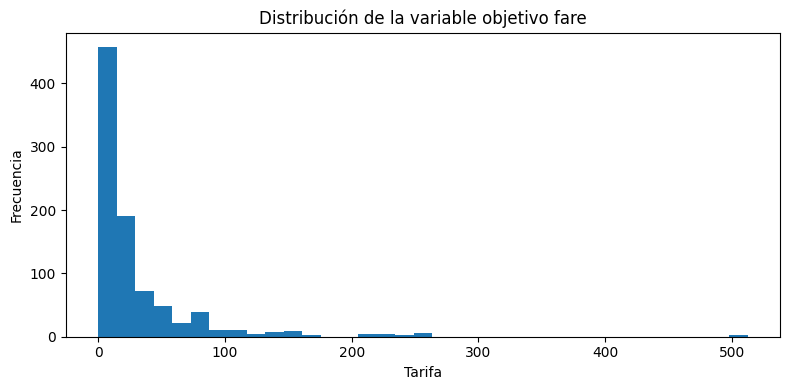

In [4]:
# Resume la distribución de la tarifa
resumen_fare = y_reg.describe().to_frame('fare')
display(resumen_fare)

# Visualiza asimetría y valores extremos de fare
plt.figure(figsize=(8,4))
plt.hist(y_reg, bins=35)
plt.title('Distribución de la variable objetivo fare')
plt.xlabel('Tarifa')
plt.ylabel('Frecuencia')
plt.tight_layout()
# Guarda la figura en PNG antes de mostrarla
plt.savefig(FIG_DIR / '01_distribucion_fare.png', dpi=180, bbox_inches='tight')
plt.show()

## 3. Implementación inicial de modelos de regresión

Se implementan cuatro enfoques para disponer de una comparación técnica: regresión lineal múltiple, árbol de decisión, Random Forest y SVR. **SVR** se escala mediante `StandardScaler`, porque su comportamiento depende de distancias en el espacio de características.

In [5]:
# Define cuatro modelos con una base experimental común
modelos_reg_iniciales = {
    'Regresión lineal múltiple': LinearRegression(),
    'Árbol de decisión': DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=8, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'SVR inicial': Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR(C=1.0, epsilon=0.1, gamma='scale'))
    ])
}

# Entrena y evalúa cada modelo sobre el conjunto de prueba
resultados_reg = []
predicciones_reg = {}
for nombre, modelo in modelos_reg_iniciales.items():
    modelo.fit(X_reg_train, y_reg_train)
    pred = modelo.predict(X_reg_test)
    predicciones_reg[nombre] = pred
    mse = mean_squared_error(y_reg_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_reg_test, pred)
    resultados_reg.append([nombre, mse, rmse, r2])

# Consolida las métricas iniciales
resultados_reg_df = pd.DataFrame(resultados_reg, columns=['Modelo','MSE','RMSE','R2']).sort_values('RMSE')
display(resultados_reg_df.style.format({'MSE':'{:.3f}','RMSE':'{:.3f}','R2':'{:.4f}'}))

,Modelo,MSE,RMSE,R2
0,Regresión lineal múltiple,928.613,30.473,0.3999
3,SVR inicial,1142.366,33.799,0.2618
2,Random Forest,1370.929,37.026,0.1141
1,Árbol de decisión,1515.252,38.926,0.0208


## 4. Ajuste de hiperparámetros del modelo de regresión

Se ajusta **SVR**, porque el desempeño de este algoritmo depende de parámetros como `C`, `epsilon` y `gamma`. La búsqueda utiliza validación cruzada de 5 particiones sobre el conjunto de entrenamiento y optimiza RMSE. El conjunto de prueba se conserva para la evaluación final.

In [6]:
# Integra escalamiento y SVR en un solo pipeline
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

# Define combinaciones de hiperparámetros para evaluar
param_grid = {
    'svr__C': [1, 10, 50, 100],
    'svr__epsilon': [0.05, 0.1, 0.5, 1.0],
    'svr__gamma': ['scale', 'auto']
}

# Busca la configuración con menor RMSE mediante validación cruzada
busqueda_svr = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    return_train_score=False
)
busqueda_svr.fit(X_reg_train, y_reg_train)

# Ordena los mejores resultados de validación
cv_svr = pd.DataFrame(busqueda_svr.cv_results_)[
    ['param_svr__C','param_svr__epsilon','param_svr__gamma','mean_test_score','rank_test_score']
].copy()
cv_svr['RMSE_CV'] = -cv_svr['mean_test_score']
cv_svr = cv_svr.sort_values('rank_test_score').drop(columns='mean_test_score')

print('Mejores hiperparámetros:', busqueda_svr.best_params_)
print('Mejor RMSE CV:', round(-busqueda_svr.best_score_, 4))
display(cv_svr.head(10).style.format({'RMSE_CV':'{:.3f}'}))

Mejores hiperparámetros: {'svr__C': 100, 'svr__epsilon': 0.1, 'svr__gamma': 'scale'}
Mejor RMSE CV: 36.1026


,param_svr__C,param_svr__epsilon,param_svr__gamma,rank_test_score,RMSE_CV
27,100,0.100000,auto,1,36.103
26,100,0.100000,scale,1,36.103
25,100,0.050000,auto,3,36.103
24,100,0.050000,scale,4,36.103
29,100,0.500000,auto,5,36.122
28,100,0.500000,scale,5,36.122
31,100,1.000000,auto,7,36.164
30,100,1.000000,scale,7,36.164
22,50,1.000000,scale,9,37.146
23,50,1.000000,auto,10,37.146


### 4.1 Evaluación del SVR ajustado en prueba

La configuración seleccionada por validación cruzada se evalúa una sola vez sobre el conjunto de prueba. Esto permite comparar de forma justa la versión inicial y la versión ajustada.

In [7]:
# Recupera el mejor SVR y predice datos no vistos
svr_ajustado = busqueda_svr.best_estimator_
pred_svr_ajustado = svr_ajustado.predict(X_reg_test)

# Calcula las métricas finales del modelo ajustado
mse = mean_squared_error(y_reg_test, pred_svr_ajustado)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_test, pred_svr_ajustado)
resultado_svr_ajustado = pd.DataFrame({
    'Modelo':['SVR ajustado'], 'MSE':[mse], 'RMSE':[rmse], 'R2':[r2]
})
display(resultado_svr_ajustado.style.format({'MSE':'{:.3f}','RMSE':'{:.3f}','R2':'{:.4f}'}))

,Modelo,MSE,RMSE,R2
0,SVR ajustado,640.286,25.304,0.5862


## 5. Evaluación y comparación técnica de regresión

Para cada modelo se reportan **MSE**, **RMSE** y **R²**. Un MSE/RMSE menor indica menor error; un R² mayor indica que el modelo explica una mayor proporción de la variabilidad observada en `fare`.

,Modelo,MSE,RMSE,R2
0,SVR ajustado,640.286,25.304,0.5862
1,Regresión lineal múltiple,928.613,30.473,0.3999
2,SVR inicial,1142.366,33.799,0.2618
3,Random Forest,1370.929,37.026,0.1141
4,Árbol de decisión,1515.252,38.926,0.0208


Mejor modelo de regresión: SVR ajustado | RMSE=25.304 | R²=0.5862


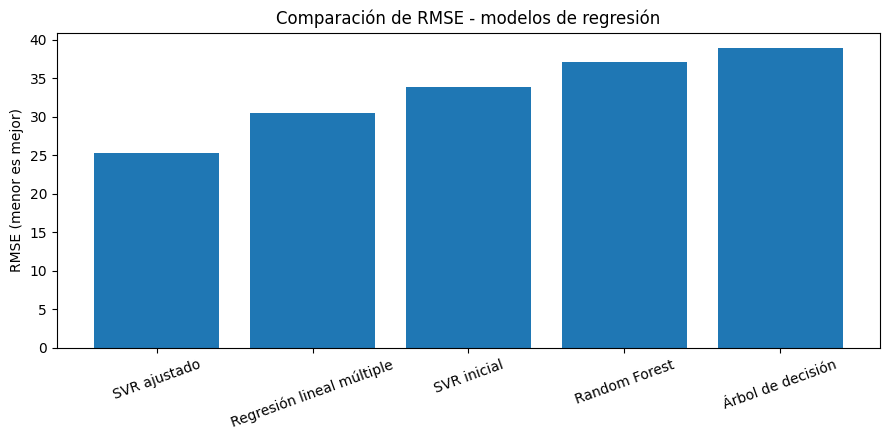

In [8]:
# Compara modelos iniciales y SVR ajustado
comparacion_reg = pd.concat([resultados_reg_df, resultado_svr_ajustado], ignore_index=True)
comparacion_reg = comparacion_reg.sort_values('RMSE').reset_index(drop=True)
display(comparacion_reg.style.format({'MSE':'{:.3f}','RMSE':'{:.3f}','R2':'{:.4f}'}))

# Identifica el modelo con menor RMSE
mejor_reg = comparacion_reg.iloc[0]
print(f"Mejor modelo de regresión: {mejor_reg['Modelo']} | RMSE={mejor_reg['RMSE']:.3f} | R²={mejor_reg['R2']:.4f}")

# Visualiza el error de cada modelo
fig, ax = plt.subplots(figsize=(9,4.5))
ax.bar(comparacion_reg['Modelo'], comparacion_reg['RMSE'])
ax.set_title('Comparación de RMSE - modelos de regresión')
ax.set_ylabel('RMSE (menor es mejor)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
# Guarda la figura en PNG antes de mostrarla
plt.savefig(FIG_DIR / '02_comparacion_rmse_regresion.png', dpi=180, bbox_inches='tight')
plt.show()

### 5.1 Interpretación técnica

La comparación permite separar **desempeño inicial** de **desempeño después del ajuste**. El SVR ajustado mejora respecto de su configuración inicial y se selecciona por presentar el menor RMSE y el mayor R² en esta partición. Aun así, el R² no representa causalidad ni garantiza desempeño futuro; los resultados están condicionados por el tamaño del dataset, la partición utilizada y la presencia de tarifas extremas.

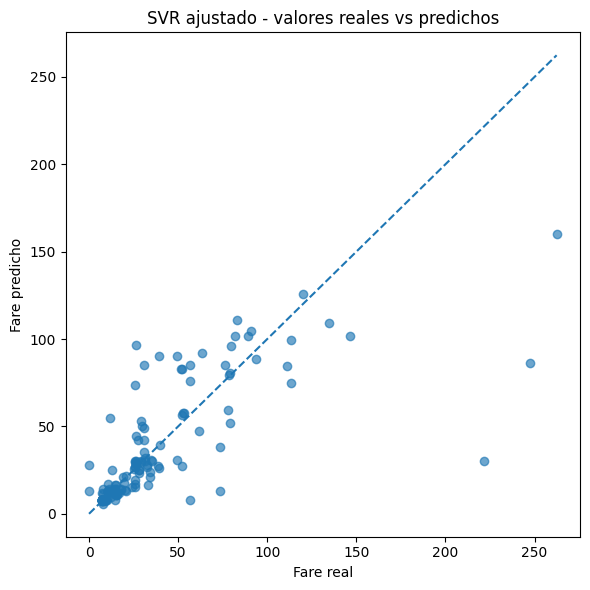

In [9]:
# Contrasta tarifas reales y predichas por el SVR ajustado
plt.figure(figsize=(6,6))
plt.scatter(y_reg_test, pred_svr_ajustado, alpha=0.65)
# Usa una escala común para la línea de predicción perfecta
lim = max(float(y_reg_test.max()), float(pred_svr_ajustado.max()))
plt.plot([0, lim], [0, lim], linestyle='--')
plt.xlabel('Fare real')
plt.ylabel('Fare predicho')
plt.title('SVR ajustado - valores reales vs predichos')
plt.tight_layout()
# Guarda la figura en PNG antes de mostrarla
plt.savefig(FIG_DIR / '03_svr_real_vs_predicho.png', dpi=180, bbox_inches='tight')
plt.show()

# FASE 3 - Clasificación supervisada con redes neuronales

## 6. Descripción y preparación para clasificación

**Objetivo:** predecir `survived` (0 = no sobrevivió, 1 = sobrevivió). Se conserva el preprocesamiento del ejemplo del profesor: eliminación de columnas redundantes o con alta ausencia, imputación de `age` y `embarked`, one-hot encoding, partición 80/20 y escalamiento con `StandardScaler` ajustado solo sobre entrenamiento.

In [10]:
# Copia y limpia las variables del problema de clasificación
clf_df = titanic_df.copy()
columnas_eliminar = ['deck','class','who','adult_male','embark_town','alive','alone']
clf_df = clf_df.drop(columns=columnas_eliminar)
clf_df['age'] = clf_df['age'].fillna(clf_df['age'].median())
clf_df['embarked'] = clf_df['embarked'].fillna(clf_df['embarked'].mode()[0])
clf_df = pd.get_dummies(clf_df, columns=['sex','embarked'], drop_first=True)

# Separa predictores, objetivo y conjuntos de evaluación
X_clf = clf_df.drop(columns='survived')
y_clf = clf_df['survived']
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=RANDOM_STATE
)

# Ajusta el escalador solo con datos de entrenamiento
scaler_clf = StandardScaler()
X_clf_train_scaled = scaler_clf.fit_transform(X_clf_train)
X_clf_test_scaled = scaler_clf.transform(X_clf_test)

print('Predictores:', X_clf.columns.tolist())
print('Nulos después del preprocesamiento:', int(clf_df.isna().sum().sum()))
print('Entrenamiento:', X_clf_train.shape, 'Prueba:', X_clf_test.shape)

Predictores: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S']
Nulos después del preprocesamiento: 0
Entrenamiento: (712, 8) Prueba: (179, 8)


## 7. Análisis exploratorio inicial para clasificación

Se revisan distribución de clases, calidad de datos y patrones descriptivos relevantes. Existe un desbalance moderado (más no sobrevivientes que sobrevivientes), por lo que se interpretan Accuracy, Precision, Recall y F1-score de forma conjunta.

,Clase,Frecuencia,Porcentaje
0,No sobrevivió (0),549,61.62%
1,Sobrevivió (1),342,38.38%


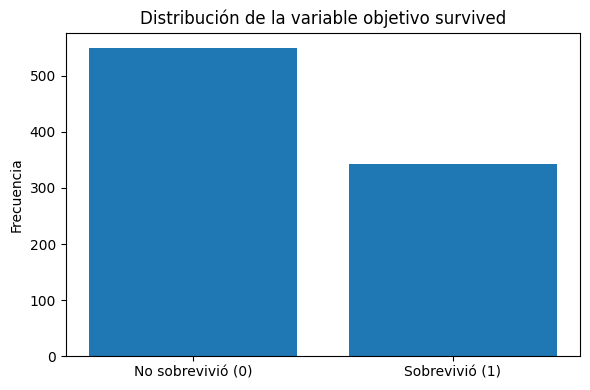

,faltantes
deck,688
age,177
embarked,2
embark_town,2


Supervivencia por sexo:


,tasa_supervivencia,count
sex,,
female,0.742,314
male,0.189,577


Supervivencia por clase de pasaje:


,tasa_supervivencia,count
pclass,,
1,0.630,216
2,0.473,184
3,0.242,491


In [11]:
# Resume y visualiza la distribución de clases
clases = titanic_df['survived'].value_counts().sort_index()
clases_df = pd.DataFrame({
    'Clase':['No sobrevivió (0)','Sobrevivió (1)'],
    'Frecuencia':[int(clases.get(0,0)), int(clases.get(1,0))]
})
clases_df['Porcentaje'] = 100*clases_df['Frecuencia']/clases_df['Frecuencia'].sum()
display(clases_df.style.format({'Porcentaje':'{:.2f}%'}))

plt.figure(figsize=(6,4))
plt.bar(clases_df['Clase'], clases_df['Frecuencia'])
plt.title('Distribución de la variable objetivo survived')
plt.ylabel('Frecuencia')
plt.tight_layout()
# Guarda la figura en PNG antes de mostrarla
plt.savefig(FIG_DIR / '04_distribucion_clases.png', dpi=180, bbox_inches='tight')
plt.show()

# Identifica valores faltantes del dataset original
faltantes = titanic_df.isna().sum().sort_values(ascending=False)
display(faltantes[faltantes>0].to_frame('faltantes'))

# Compara patrones descriptivos por sexo y clase de pasaje
patron_sexo = titanic_df.groupby('sex', observed=True)['survived'].agg(['mean','count']).rename(columns={'mean':'tasa_supervivencia'})
patron_clase = titanic_df.groupby('pclass', observed=True)['survived'].agg(['mean','count']).rename(columns={'mean':'tasa_supervivencia'})
print('Supervivencia por sexo:')
display(patron_sexo.style.format({'tasa_supervivencia':'{:.3f}'}))
print('Supervivencia por clase de pasaje:')
display(patron_clase.style.format({'tasa_supervivencia':'{:.3f}'}))

## 8. Función común de evaluación

La misma función calcula métricas y matriz de confusión para las tres arquitecturas, garantizando consistencia en el reporte.

In [12]:
# Aplica las mismas métricas a cada arquitectura MLP
def evaluar_clasificador(nombre, modelo, X_test, y_test):
    # Genera predicciones y descompone la matriz de confusión
    pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    fila = {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1-score': f1_score(y_test, pred, zero_division=0),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    }
    return fila, cm, pred

## 9. Red neuronal con una capa oculta

Arquitectura del ejemplo docente: **(100,)**, activación ReLU, optimizador Adam, `max_iter=500` y `random_state=42`.

In [13]:
# Entrena una red con una capa oculta y registra convergencia
with warnings.catch_warnings(record=True) as avisos_1:
    warnings.simplefilter('always', ConvergenceWarning)
    mlp_1 = MLPClassifier(
        hidden_layer_sizes=(100,), activation='relu', solver='adam',
        max_iter=500, random_state=RANDOM_STATE
    )
    mlp_1.fit(X_clf_train_scaled, y_clf_train)
# Evalúa la arquitectura sobre el conjunto de prueba
res_1, cm_1, pred_1 = evaluar_clasificador('MLP 1 capa oculta', mlp_1, X_clf_test_scaled, y_clf_test)
print('Iteraciones:', mlp_1.n_iter_, '| ConvergenceWarning:', any(isinstance(w.message, ConvergenceWarning) for w in avisos_1))
display(pd.DataFrame([res_1]).style.format({k:'{:.4f}' for k in ['Accuracy','Precision','Recall','F1-score']}))
display(pd.DataFrame(cm_1, index=['Real 0','Real 1'], columns=['Pred 0','Pred 1']))

Iteraciones: 500 | ConvergenceWarning: True


,Modelo,Accuracy,Precision,Recall,F1-score,TN,FP,FN,TP
0,MLP 1 capa oculta,0.8212,0.8182,0.7297,0.7714,93,12,20,54


,Pred 0,Pred 1
Real 0,93,12
Real 1,20,54


**Interpretación:** una capa oculta ofrece una arquitectura relativamente simple y competitiva. La matriz de confusión permite observar cuántos sobrevivientes reales se pierden como falsos negativos, aspecto que complementa la lectura de Accuracy.

## 10. Red neuronal con dos capas ocultas

Arquitectura: **(100, 50)**. Se mantienen ReLU, Adam, 500 iteraciones y la misma partición para que la comparación dependa principalmente de la profundidad de la red.

In [14]:
# Entrena una red con dos capas ocultas y registra convergencia
with warnings.catch_warnings(record=True) as avisos_2:
    warnings.simplefilter('always', ConvergenceWarning)
    mlp_2 = MLPClassifier(
        hidden_layer_sizes=(100,50), activation='relu', solver='adam',
        max_iter=500, random_state=RANDOM_STATE
    )
    mlp_2.fit(X_clf_train_scaled, y_clf_train)
# Evalúa la arquitectura sobre el conjunto de prueba
res_2, cm_2, pred_2 = evaluar_clasificador('MLP 2 capas ocultas', mlp_2, X_clf_test_scaled, y_clf_test)
print('Iteraciones:', mlp_2.n_iter_, '| ConvergenceWarning:', any(isinstance(w.message, ConvergenceWarning) for w in avisos_2))
display(pd.DataFrame([res_2]).style.format({k:'{:.4f}' for k in ['Accuracy','Precision','Recall','F1-score']}))
display(pd.DataFrame(cm_2, index=['Real 0','Real 1'], columns=['Pred 0','Pred 1']))

Iteraciones: 500 | ConvergenceWarning: True


,Modelo,Accuracy,Precision,Recall,F1-score,TN,FP,FN,TP
0,MLP 2 capas ocultas,0.8156,0.8154,0.7162,0.7626,93,12,21,53


,Pred 0,Pred 1
Real 0,93,12
Real 1,21,53


**Interpretación:** agregar una segunda capa aumenta la capacidad representacional, pero mayor complejidad no garantiza una mejora automática. El resultado debe contrastarse con las otras arquitecturas y no evaluarse solo por profundidad.

## 11. Red neuronal con tres capas ocultas

Arquitectura: **(100, 50, 25)**, con los mismos parámetros de activación, solver, iteraciones máximas y semilla.

In [15]:
# Entrena una red con tres capas ocultas y registra convergencia
with warnings.catch_warnings(record=True) as avisos_3:
    warnings.simplefilter('always', ConvergenceWarning)
    mlp_3 = MLPClassifier(
        hidden_layer_sizes=(100,50,25), activation='relu', solver='adam',
        max_iter=500, random_state=RANDOM_STATE
    )
    mlp_3.fit(X_clf_train_scaled, y_clf_train)
# Evalúa la arquitectura sobre el conjunto de prueba
res_3, cm_3, pred_3 = evaluar_clasificador('MLP 3 capas ocultas', mlp_3, X_clf_test_scaled, y_clf_test)
print('Iteraciones:', mlp_3.n_iter_, '| ConvergenceWarning:', any(isinstance(w.message, ConvergenceWarning) for w in avisos_3))
display(pd.DataFrame([res_3]).style.format({k:'{:.4f}' for k in ['Accuracy','Precision','Recall','F1-score']}))
display(pd.DataFrame(cm_3, index=['Real 0','Real 1'], columns=['Pred 0','Pred 1']))

Iteraciones: 289 | ConvergenceWarning: False


,Modelo,Accuracy,Precision,Recall,F1-score,TN,FP,FN,TP
0,MLP 3 capas ocultas,0.8268,0.8116,0.7568,0.7832,92,13,18,56


,Pred 0,Pred 1
Real 0,92,13
Real 1,18,56


**Interpretación:** la red de tres capas tiene mayor profundidad y, en esta ejecución, debe evaluarse por su balance entre Accuracy, Recall y F1-score, además del número de falsos negativos. Su mayor complejidad implica también menor interpretabilidad y mayor necesidad de validación posterior.

## 12. Desempeño de redes neuronales

Se consolidan métricas y matrices de confusión para las tres arquitecturas sobre el **mismo conjunto de prueba**.

,Modelo,Accuracy,Precision,Recall,F1-score,TN,FP,FN,TP
0,MLP 1 capa oculta,0.8212,0.8182,0.7297,0.7714,93,12,20,54
1,MLP 2 capas ocultas,0.8156,0.8154,0.7162,0.7626,93,12,21,53
2,MLP 3 capas ocultas,0.8268,0.8116,0.7568,0.7832,92,13,18,56


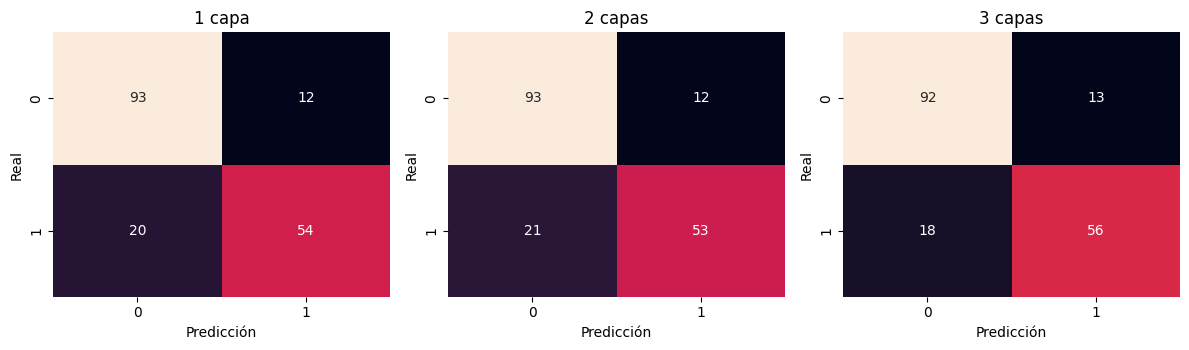

In [16]:
# Consolida las métricas de las tres arquitecturas
metricas_mlp = pd.DataFrame([res_1,res_2,res_3])
display(metricas_mlp.style.format({k:'{:.4f}' for k in ['Accuracy','Precision','Recall','F1-score']}))

# Compara visualmente sus matrices de confusión
fig, axes = plt.subplots(1,3,figsize=(12,3.6))
for ax, cm, titulo in zip(axes,[cm_1,cm_2,cm_3],['1 capa','2 capas','3 capas']):
    sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
plt.tight_layout()
# Guarda la figura en PNG antes de mostrarla
plt.savefig(FIG_DIR / '05_matrices_confusion_mlp.png', dpi=180, bbox_inches='tight')
plt.show()

## 13. Comparación de arquitecturas de redes neuronales

La selección no se basa en una sola métrica. Accuracy resume aciertos globales; Recall es importante para la clase positiva; F1-score equilibra Precision y Recall; y la matriz de confusión muestra el tipo de error cometido.

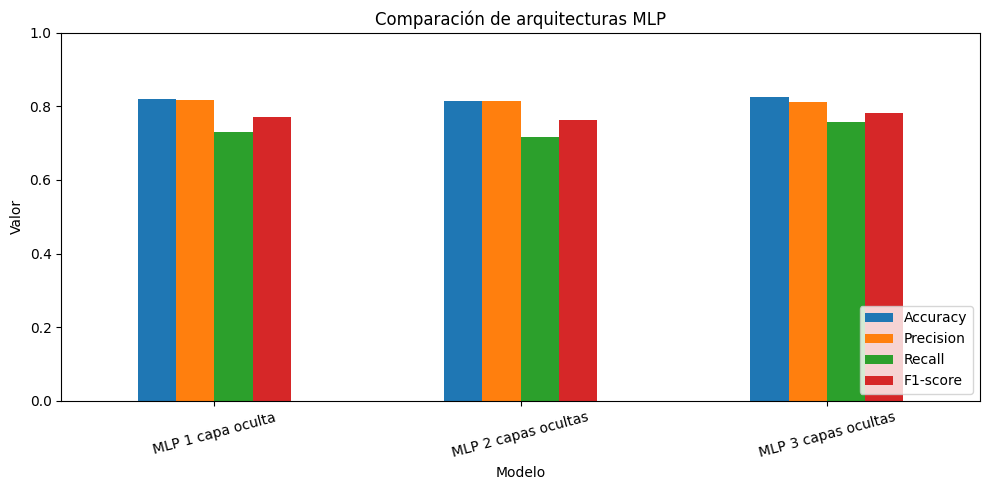

Arquitectura seleccionada preliminarmente: MLP 3 capas ocultas
Accuracy=0.8268 | Recall=0.7568 | F1=0.7832


In [17]:
# Compara Accuracy, Precision, Recall y F1-score
metricas_long = metricas_mlp.set_index('Modelo')[['Accuracy','Precision','Recall','F1-score']]
ax = metricas_long.plot(kind='bar', figsize=(10,5))
ax.set_ylim(0,1)
ax.set_ylabel('Valor')
ax.set_title('Comparación de arquitecturas MLP')
ax.legend(loc='lower right')
plt.xticks(rotation=15)
plt.tight_layout()
# Guarda la figura en PNG antes de mostrarla
plt.savefig(FIG_DIR / '06_comparacion_arquitecturas_mlp.png', dpi=180, bbox_inches='tight')
plt.show()

# Selecciona preliminarmente la arquitectura con mejor F1
mejor_f1 = metricas_mlp.sort_values(['F1-score','Accuracy'], ascending=False).iloc[0]
print(f"Arquitectura seleccionada preliminarmente: {mejor_f1['Modelo']}")
print(f"Accuracy={mejor_f1['Accuracy']:.4f} | Recall={mejor_f1['Recall']:.4f} | F1={mejor_f1['F1-score']:.4f}")

### 13.1 Fortalezas y limitaciones

| Arquitectura | Fortaleza | Limitación |
|---|---|---|
| 1 capa (100) | Menor complejidad y desempeño competitivo | Puede no capturar interacciones tan complejas; alcanza el máximo de iteraciones en esta ejecución |
| 2 capas (100, 50) | Mayor capacidad representacional | No mejora automáticamente las métricas y también alcanza el máximo de iteraciones |
| 3 capas (100, 50, 25) | Mejor balance observado de Accuracy, Recall y F1-score | Mayor complejidad y menor interpretabilidad; requiere validación externa |

La decisión preliminar favorece la arquitectura de tres capas **solo para esta partición y configuración**. Una conclusión definitiva requeriría validación cruzada y ajuste de hiperparámetros, tareas que no se confunden con la evidencia requerida en esta entrega.

# **14. Conclusiones integradas de Fases 2 y 3**

1. **Fase 2 - regresión:** la preparación permitió trabajar con una variable objetivo continua (`fare`), sin valores faltantes y con predictores numéricos y categóricos transformados. La comparación inicial mostró diferencias entre los algoritmos evaluados. El ajuste de `C`, `epsilon` y `gamma` mejoró el desempeño de SVR, que obtuvo el menor RMSE y el mayor R² en la partición utilizada.

2. **Fase 3 - clasificación:** la preparación transformó el conjunto Titanic en una matriz numérica completa y escalada para el entrenamiento de las redes neuronales. Debido al desbalance moderado de clases, Accuracy se interpretó en conjunto con Precision, Recall y F1-score.

3. **Arquitecturas MLP:** la red de tres capas ocultas obtuvo el mejor balance global entre las arquitecturas evaluadas en esta ejecución, con los mayores valores de Accuracy, Recall y F1-score. Las redes de una y dos capas presentaron resultados cercanos, aunque con menor desempeño global.

4. **Relación entre preparación y desempeño:** la imputación permitió conservar las observaciones disponibles, la codificación convirtió las variables categóricas en características utilizables por los modelos y el escalamiento permitió trabajar con SVR y MLP bajo una escala común de variables.

5. **Alcance de los resultados:** las selecciones realizadas corresponden a las configuraciones, variables y partición de datos utilizadas en este experimento. Por lo tanto, los resultados deben interpretarse dentro de este contexto y no como evidencia de superioridad definitiva entre modelos ni de relaciones causales.


# 15. Fuentes y referencias

**Material docente**

- Ruete Zúñiga, D. (2026a). *Evaluación Sumativa 2: Informe Final de Proyecto - Fases 2 y 3* [Instrucciones de actividad]. Universidad Andrés Bello.
- Ruete Zúñiga, D. (2026b). *fase_3_entregable_semana_3_sumativa.ipynb* [Notebook de apoyo docente]. Universidad Andrés Bello.

**Documentación técnica oficial**

- scikit-learn Developers. (s. f.). *sklearn.svm.SVR*. Scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html
- scikit-learn Developers. (s. f.). *sklearn.neural_network.MLPClassifier*. Scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
- scikit-learn Developers. (s. f.). *GridSearchCV*. Scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

**Fuentes académicas complementarias**

- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.
- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical learning: With applications in Python*. Springer.